In [1]:
from pathlib import Path
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier


In [2]:
warnings.filterwarnings("ignore")
SEED = 42
TEXT_COL = "clean_text"
LABEL_COL = "label"
NUMERIC_COLS = [
    "char_count",
    "word_count",
    "has_link",
    "has_mention",
    "has_hashtag",
    "is_retweet",
    "exclamation_count",
    "question_count",
]

try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    BASE_DIR = Path.cwd()

OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR = OUTPUT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)


In [3]:
def _find_csv(name: str) -> Path:
    candidates = [
        OUTPUT_DIR / name,
        BASE_DIR / name,
        Path("outputs") / name,
        Path(name),
        Path("/mnt/data") / name,
        Path("/work/outputs") / name,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {name}. Checked: {candidates}")

In [4]:
def load_splits():
    train_df = pd.read_csv(_find_csv("train.csv"))
    valid_df = pd.read_csv(_find_csv("valid.csv"))
    test_df = pd.read_csv(_find_csv("test.csv"))
    return train_df, valid_df, test_df

In [5]:
def prepare_labels(train_df, valid_df, test_df):
    le = LabelEncoder()
    y_train = le.fit_transform(train_df[LABEL_COL])
    y_valid = le.transform(valid_df[LABEL_COL])
    y_test = le.transform(test_df[LABEL_COL])
    return le, y_train, y_valid, y_test

In [6]:
def build_feature_set(train_df, valid_df, test_df, use_word=True, use_char=False, use_numeric=False):
    pieces_train, pieces_valid, pieces_test = [], [], []
    feature_info = {}

    if use_word:
        word_vec = TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            strip_accents="unicode",
        )
        Xw_train = word_vec.fit_transform(train_df[TEXT_COL].fillna(""))
        Xw_valid = word_vec.transform(valid_df[TEXT_COL].fillna(""))
        Xw_test = word_vec.transform(test_df[TEXT_COL].fillna(""))
        pieces_train.append(Xw_train)
        pieces_valid.append(Xw_valid)
        pieces_test.append(Xw_test)
        feature_info["word_vectorizer"] = word_vec

    if use_char:
        char_vec = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=3,
            sublinear_tf=True,
        )
        Xc_train = char_vec.fit_transform(train_df[TEXT_COL].fillna(""))
        Xc_valid = char_vec.transform(valid_df[TEXT_COL].fillna(""))
        Xc_test = char_vec.transform(test_df[TEXT_COL].fillna(""))
        pieces_train.append(Xc_train)
        pieces_valid.append(Xc_valid)
        pieces_test.append(Xc_test)
        feature_info["char_vectorizer"] = char_vec

    if use_numeric:
        Xn_train = sp.csr_matrix(train_df[NUMERIC_COLS].astype(float).values)
        Xn_valid = sp.csr_matrix(valid_df[NUMERIC_COLS].astype(float).values)
        Xn_test = sp.csr_matrix(test_df[NUMERIC_COLS].astype(float).values)
        pieces_train.append(Xn_train)
        pieces_valid.append(Xn_valid)
        pieces_test.append(Xn_test)
        feature_info["numeric_columns"] = NUMERIC_COLS

    X_train = sp.hstack(pieces_train, format="csr") if len(pieces_train) > 1 else pieces_train[0]
    X_valid = sp.hstack(pieces_valid, format="csr") if len(pieces_valid) > 1 else pieces_valid[0]
    X_test = sp.hstack(pieces_test, format="csr") if len(pieces_test) > 1 else pieces_test[0]
    return X_train, X_valid, X_test, feature_info

In [7]:
def evaluate_predictions(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }


In [8]:
def run_experiments(train_df, valid_df, test_df):
    le, y_train, y_valid, y_test = prepare_labels(train_df, valid_df, test_df)

    feature_configs = {
        "word_tfidf": dict(use_word=True, use_char=False, use_numeric=False),
        "word_plus_numeric": dict(use_word=True, use_char=False, use_numeric=True),
        "word_char": dict(use_word=True, use_char=True, use_numeric=False),
        "word_char_numeric": dict(use_word=True, use_char=True, use_numeric=True),
    }

    model_configs = {
        "ComplementNB": ComplementNB(alpha=0.5),
        "LinearSVC": LinearSVC(C=1.0),
        "SGD_logistic": SGDClassifier(
            loss="log_loss",
            alpha=1e-5,
            max_iter=40,
            random_state=SEED,
            n_jobs=-1,
        ),
    }

    rows = []
    fitted_artifacts = {}

    for feat_name, feat_kwargs in feature_configs.items():
        X_train, X_valid, X_test, feature_info = build_feature_set(
            train_df, valid_df, test_df, **feat_kwargs
        )

        for model_name, base_model in model_configs.items():
            model = clone(base_model)
            model.fit(X_train, y_train)

            valid_pred = model.predict(X_valid)
            valid_metrics = evaluate_predictions(y_valid, valid_pred)
            rows.append({
                "feature_set": feat_name,
                "model": model_name,
                "split": "valid",
                **valid_metrics,
            })

            test_pred = model.predict(X_test)
            test_metrics = evaluate_predictions(y_test, test_pred)
            rows.append({
                "feature_set": feat_name,
                "model": model_name,
                "split": "test",
                **test_metrics,
            })

            fitted_artifacts[(feat_name, model_name)] = {
                "model": model,
                "feature_info": feature_info,
                "X_valid": X_valid,
                "X_test": X_test,
                "y_valid": y_valid,
                "y_test": y_test,
                "valid_pred": valid_pred,
                "test_pred": test_pred,
                "label_encoder": le,
            }

    results_df = pd.DataFrame(rows).sort_values(
        by=["split", "f1_macro", "accuracy"], ascending=[True, False, False]
    )
    results_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
    return results_df, fitted_artifacts, le


In [9]:
def plot_model_comparison(results_df):
    valid_df = results_df[results_df["split"] == "valid"].copy()
    valid_df = valid_df.sort_values("f1_macro", ascending=True)
    labels = valid_df["model"] + "\n" + valid_df["feature_set"]

    plt.figure(figsize=(12, 8))
    plt.barh(labels, valid_df["f1_macro"])
    plt.xlabel("Validation Macro F1")
    plt.ylabel("Experiment")
    plt.title("Model Comparison on Validation Set")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ml_model_comparison.png", dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()


In [10]:
def pick_best_model(results_df):
    valid_df = results_df[results_df["split"] == "valid"].copy()
    best_row = valid_df.sort_values(["f1_macro", "accuracy"], ascending=False).iloc[0]
    return best_row

In [11]:
def save_final_reports(best_row, fitted_artifacts):
    key = (best_row["feature_set"], best_row["model"])
    artifact = fitted_artifacts[key]
    le = artifact["label_encoder"]

    y_test = artifact["y_test"]
    y_pred = artifact["test_pred"]
    class_names = le.classes_

    report_dict = classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T
    report_df.to_csv(OUTPUT_DIR / "best_model_test_classification_report.csv")

    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    cm_df.to_csv(OUTPUT_DIR / "best_model_confusion_matrix.csv")

    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
    plt.title(f"Confusion Matrix - {best_row['model']} + {best_row['feature_set']}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "best_model_confusion_matrix.png", dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    report_only_classes = report_df.loc[class_names].copy()
    report_only_classes = report_only_classes.sort_values("f1-score", ascending=True)
    plt.figure(figsize=(10, 6))
    plt.barh(report_only_classes.index, report_only_classes["f1-score"])
    plt.xlabel("Test F1-score")
    plt.ylabel("Emoji")
    plt.title("Best Model: Per-Class F1-score")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "best_model_per_class_f1.png", dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

    mistakes = []
    for i, true_name in enumerate(class_names):
        for j, pred_name in enumerate(class_names):
            if i != j and cm[i, j] > 0:
                mistakes.append({
                    "true_label": true_name,
                    "predicted_label": pred_name,
                    "count": int(cm[i, j]),
                })
    top_confusions = pd.DataFrame(mistakes).sort_values("count", ascending=False).head(15)
    top_confusions.to_csv(OUTPUT_DIR / "top_confusions.csv", index=False)

    return report_df, top_confusions

In [12]:
def fit_best_model_on_train_plus_valid(best_row, train_df, valid_df, test_df):
    combined_train = pd.concat([train_df, valid_df], ignore_index=True)
    le = LabelEncoder()
    y_train_full = le.fit_transform(combined_train[LABEL_COL])
    y_test = le.transform(test_df[LABEL_COL])

    feat_map = {
        "word_tfidf": dict(use_word=True, use_char=False, use_numeric=False),
        "word_plus_numeric": dict(use_word=True, use_char=False, use_numeric=True),
        "word_char": dict(use_word=True, use_char=True, use_numeric=False),
        "word_char_numeric": dict(use_word=True, use_char=True, use_numeric=True),
    }
    model_map = {
        "ComplementNB": ComplementNB(alpha=0.5),
        "LinearSVC": LinearSVC(C=1.0),
        "SGD_logistic": SGDClassifier(
            loss="log_loss",
            alpha=1e-5,
            max_iter=40,
            random_state=SEED,
            n_jobs=-1,
        ),
    }

    X_train_full, _, X_test, feature_info = build_feature_set(
        combined_train,
        valid_df.iloc[:1].copy(),
        test_df,
        **feat_map[best_row["feature_set"]],
    )
    # rebuild correctly for test after using a dummy valid frame for vectorizer fitting
    X_train_full, _, X_test, feature_info = build_feature_set(
        combined_train,
        combined_train.iloc[:1].copy(),
        test_df,
        **feat_map[best_row["feature_set"]],
    )

    final_model = clone(model_map[best_row["model"]])
    final_model.fit(X_train_full, y_train_full)
    final_test_pred = final_model.predict(X_test)
    final_metrics = evaluate_predictions(y_test, final_test_pred)

    joblib.dump(
        {
            "model": final_model,
            "label_encoder": le,
            "feature_info": feature_info,
            "text_col": TEXT_COL,
            "numeric_cols": NUMERIC_COLS,
            "feature_set": best_row["feature_set"],
            "model_name": best_row["model"],
        },
        MODEL_DIR / "best_emoji_model.joblib",
    )

    with open(OUTPUT_DIR / "best_model_summary.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "best_validation_model": best_row.to_dict(),
                "retrained_test_metrics": final_metrics,
            },
            f,
            indent=2,
        )

    return final_metrics

In [13]:
def show_linear_keywords(best_row, fitted_artifacts, top_n=12):
    key = (best_row["feature_set"], best_row["model"])
    artifact = fitted_artifacts[key]
    model = artifact["model"]
    le = artifact["label_encoder"]
    feature_info = artifact["feature_info"]

    if not hasattr(model, "coef_") or "word_vectorizer" not in feature_info:
        print("Top keyword display is only available for linear text models.")
        return None

    word_features = feature_info["word_vectorizer"].get_feature_names_out()
    coef = model.coef_[:, : len(word_features)]

    rows = []
    for class_idx, class_name in enumerate(le.classes_):
        top_idx = np.argsort(coef[class_idx])[-top_n:][::-1]
        top_terms = ", ".join(word_features[top_idx])
        rows.append({"label": class_name, "top_positive_terms": top_terms})

    keywords_df = pd.DataFrame(rows)
    keywords_df.to_csv(OUTPUT_DIR / "top_keywords_per_emoji.csv", index=False)
    return keywords_df

In [14]:
def build_presentation_notes(results_df, best_row, top_confusions, dataset_path=None):
    valid_df = results_df[results_df["split"] == "valid"].sort_values("f1_macro", ascending=False)
    test_df = results_df[results_df["split"] == "test"].sort_values("f1_macro", ascending=False)

    notes = {
        "problem": "Predict the emoji label from tweet text.",
        "best_validation_experiment": best_row.to_dict(),
        "top_3_validation_models": valid_df.head(3).to_dict(orient="records"),
        "top_3_test_models": test_df.head(3).to_dict(orient="records"),
        "top_confusions": top_confusions.head(10).to_dict(orient="records"),
    }

    with open(OUTPUT_DIR / "presentation_notes.json", "w", encoding="utf-8") as f:
        json.dump(notes, f, indent=2)
    return notes

In [19]:
def main():
    train_df, valid_df, test_df = load_splits()
    print("Train shape:", train_df.shape)
    print("Valid shape:", valid_df.shape)
    print("Test shape:", test_df.shape)

    results_df, fitted_artifacts, _ = run_experiments(train_df, valid_df, test_df)
    print("\n=== Model comparison ===")
    print(results_df.head(20).to_string(index=False))

    plot_model_comparison(results_df)

    best_row = pick_best_model(results_df)
    print("\n=== Best Validation Model ===")
    print(best_row)

    report_df, top_confusions = save_final_reports(best_row, fitted_artifacts)
    print("\n=== Best Model Classification Report (Test) ===")
    print(report_df)
    print("\n=== Top Confusions ===")
    print(top_confusions)

    keywords_df = show_linear_keywords(best_row, fitted_artifacts)
    if keywords_df is not None:
        print("\n=== Top Keywords Per Emoji ===")
        print(keywords_df.head(10).to_string(index=False))

    final_metrics = fit_best_model_on_train_plus_valid(best_row, train_df, valid_df, test_df)
    print("\n=== Retrained Best Model on Train+Valid, Evaluated on Test ===")
    print(final_metrics)

Train shape: (148049, 12)
Valid shape: (31726, 12)
Test shape: (31725, 12)

=== Model comparison ===
      feature_set        model split  accuracy  precision_macro  recall_macro  f1_macro  precision_weighted  recall_weighted  f1_weighted
        word_char    LinearSVC  test  0.528952         0.533276      0.491604  0.508055            0.530611         0.528952     0.526792
       word_tfidf    LinearSVC  test  0.525579         0.535661      0.486849  0.505352            0.528558         0.525579     0.523092
        word_char SGD_logistic  test  0.512277         0.585322      0.449609  0.484092            0.539859         0.512277     0.503649
       word_tfidf SGD_logistic  test  0.504271         0.622999      0.430909  0.472970            0.556519         0.504271     0.492477
word_plus_numeric ComplementNB  test  0.486020         0.490632      0.446876  0.461475            0.492169         0.486020     0.484419
       word_tfidf ComplementNB  test  0.485138         0.480765      0.

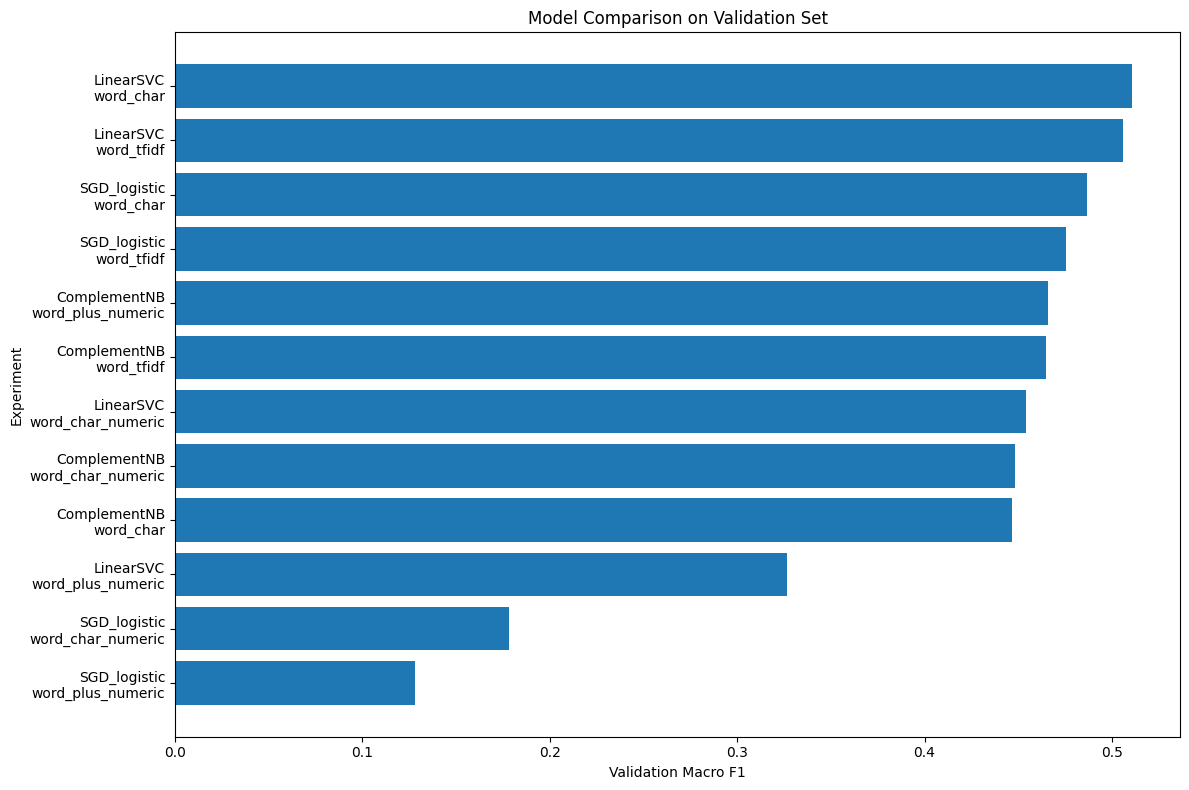


=== Best validation model ===
feature_set           word_char
model                 LinearSVC
split                     valid
accuracy               0.530669
precision_macro        0.534464
recall_macro            0.49503
f1_macro               0.510797
precision_weighted     0.531465
recall_weighted        0.530669
f1_weighted             0.52827
Name: 14, dtype: object


<Figure size 1000x800 with 0 Axes>

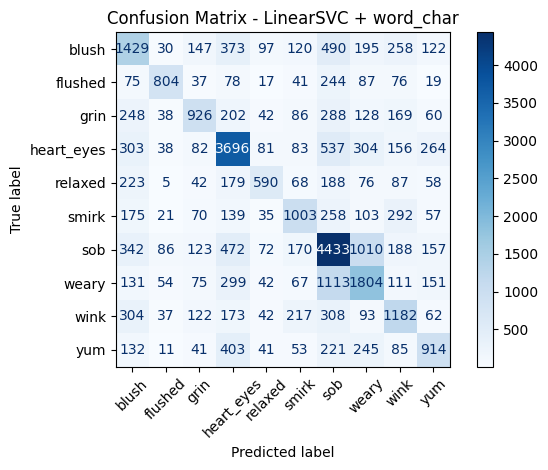

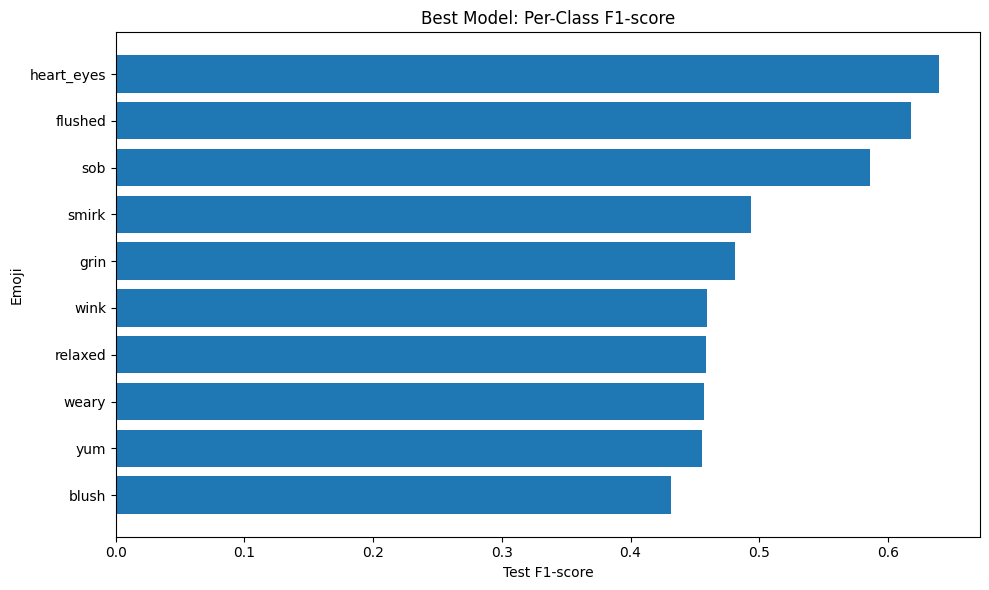


=== Best model classification report (test) ===
              precision    recall  f1-score       support
blush          0.425045  0.438209  0.431526   3261.000000
flushed        0.715302  0.543978  0.617986   1478.000000
grin           0.556156  0.423411  0.480789   2187.000000
heart_eyes     0.614566  0.666667  0.639557   5544.000000
relaxed        0.557129  0.389182  0.458252   1516.000000
smirk          0.525681  0.465862  0.493967   2153.000000
sob            0.548639  0.628527  0.585872   7053.000000
weary          0.445983  0.468937  0.457172   3847.000000
wink           0.453917  0.465354  0.459565   2540.000000
yum            0.490343  0.425909  0.455860   2146.000000
accuracy       0.528952  0.528952  0.528952      0.528952
macro avg      0.533276  0.491604  0.508055  31725.000000
weighted avg   0.530611  0.528952  0.526792  31725.000000

=== Top confusions ===
    true_label predicted_label  count
69       weary             sob   1113
60         sob           weary   1010
3

In [18]:

if __name__ == "__main__":
    main()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=62b91583-1382-466d-9446-3dc5e725c312' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>